In [1]:
import pickle
import pandas as pd
import joblib

In [2]:
model_prefix  = '../2_model_development/'
data_prefix = '../0_data/processed_data/'
non_feature_cols = ['SMILES', 'MP', 'Type', 'Ro5']
model_types = ['RF', 'XGB', 'LGB']

In [3]:
for model_type in model_types:
    model_path = f'{model_prefix}best_model_{model_type}.joblib'
    joblib.load(model_path)


/Users/zeqing/opt/anaconda3/envs/melting_point/lib/python3.11/pickle.py:1718: UserWarning: [09:52:38] WARNING: /Users/runner/work/xgboost/xgboost/src/gbm/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


In [ ]:
model_name = 'RF'
model = model_development_results_dict[model_name]['best_model_info']['model']
data = pd.read_parquet(data_prefix + f"data_with_selected_features_{model_name}_scaled.parquet")

In [7]:
data_test = data[data['Type']=='Test']
data_test

,SMILES,MP,Type,Ro5,RDKit_TPSA,RDKit_BertzCT,RDKit_NumHDonors,RDKit_RingCount,RDKit_NHOHCount,RDKit_FractionCSP3,...,RDKit_fr_Ar_COO,RDKit_Chi3v,RDKit_Chi4n,RDKit_EState_VSA2,RDKit_SMR_VSA5,RDKit_VSA_EState8,RDKit_EState_VSA4,RDKit_SMR_VSA7,RDKit_SlogP_VSA8,RDKit_SlogP_VSA1
12054,[O-][N+](=O)c1c(C)c(C(=O)C)c(c(c1C(C)(C)C)[N+]...,135.5,Test,1,1.469587,0.442559,-0.857454,-0.677491,-0.839721,0.679669,...,-0.218675,0.079057,0.467617,2.630821,0.998128,2.270969,-0.914871,0.188151,-0.467993,-0.769670
12055,CN(NC(=O)CCC(=O)O)C,154.5,Test,1,0.507304,-1.085124,0.949337,-1.446897,0.694148,1.242283,...,-0.218675,-1.008238,-0.823819,1.070382,-0.226208,-0.648216,-0.914871,-1.420751,-0.467993,0.285544
12056,CCCCc1ccc(cc1)NC(=O)Oc1ccc(cc1)OC,143.0,Test,1,-0.122990,0.360855,0.045942,0.091915,-0.072787,-0.070483,...,-0.218675,0.030133,0.069489,-0.895806,0.252697,0.041357,0.598021,0.627921,-0.467993,2.106807
12057,OC(=O)COCCN1C(=O)c2c(C1=O)cccc2,128.0,Test,1,0.914654,-0.020869,0.045942,0.091915,-0.072787,-0.164252,...,-0.218675,-0.287430,-0.092230,1.722377,-0.687065,-0.767109,-0.499754,-0.080365,-0.467993,-0.769670
12058,CCCCCCCCCCCCCCC,10.0,Test,1,-1.480634,-1.323539,-0.857454,-1.446897,-0.839721,2.367511,...,-0.218675,-0.005811,0.105820,-0.895806,2.805458,0.804767,-0.914871,-1.420751,-0.467993,-0.769670
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17215,c1ccc2c(c1)c1cc3ccc4c(c3nc1cc2)cccc4,226.0,Test,1,-1.112677,1.976777,-0.857454,2.400134,-0.839721,-1.008173,...,-0.218675,0.520770,0.837238,-0.895806,-0.687065,-0.648216,0.019870,1.565954,5.943750,-0.769670
17216,COc1cc(OC)cc(c1C#N)OC,142.0,Test,1,-0.011090,-0.462579,-0.857454,-0.677491,-0.839721,0.004532,...,-0.218675,-0.609255,-0.473341,-0.895806,-0.687065,-0.648216,-0.914871,-0.750558,-0.467993,1.994022
17217,OCCCCCCCCCCc1ccccc1,36.0,Test,1,-0.903150,-0.753977,0.045942,-0.677491,-0.072787,1.101629,...,-0.218675,-0.001753,0.138650,-0.895806,1.386791,-0.534476,-0.370904,-0.061319,-0.467993,-0.769670
17218,Clc1c2OC3Cc4c(C3Oc2c(c(c1Cl)Cl)Cl)cccc4,159.0,Test,1,-0.953676,0.923148,-0.857454,1.630727,-0.839721,-0.333036,...,-0.218675,1.033724,0.553537,2.491332,-0.018522,-0.648216,0.100427,0.680507,-0.467993,1.072791


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

def model_evaluation(data_test, model):

    non_feature_cols = ['SMILES', 'MP', 'Type', 'Ro5']

    result = data_test.copy()
    X = result.drop(columns=non_feature_cols)
    result['MP_pred'] = model.predict(X)

    # ── Compute metrics for each subset ───────────────────────────────
    subsets = {
        'Ro5 = 1':  result[result['Ro5'] == 1],
        'Ro5 = 0':  result[result['Ro5'] == 0],
        'Overall':  result,
    }

    labels, rmses, r2s = [], [], []
    for label, subset in subsets.items():
        y_true = subset['MP'].values
        y_pred = subset['MP_pred'].values
        rmses.append(np.sqrt(mean_squared_error(y_true, y_pred)))
        r2s.append(r2_score(y_true, y_pred))
        labels.append(label)

    colors = ['#4C72B0', '#DD8452', '#55A868']

    # ── Figure 1: RMSE ────────────────────────────────────────────────
    fig1, ax1 = plt.subplots(figsize=(6, 4))
    bars1 = ax1.bar(labels, rmses, color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars1, rmses):
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=11)
    ax1.set_ylabel('RMSE (°C)', fontsize=12)
    ax1.set_title('Model RMSE by Ro5 Group', fontsize=13)
    ax1.set_ylim(0, max(rmses) * 1.2)
    ax1.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    # ── Figure 2: R² ──────────────────────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(6, 4))
    bars2 = ax2.bar(labels, r2s, color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars2, r2s):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=11)
    ax2.set_ylabel('R²', fontsize=12)
    ax2.set_title('Model R² by Ro5 Group', fontsize=13)
    ax2.set_ylim(0, 1.1)
    ax2.axhline(y=1, color='grey', linestyle='--', linewidth=0.8)
    ax2.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

    return result

Evaluating model: RF


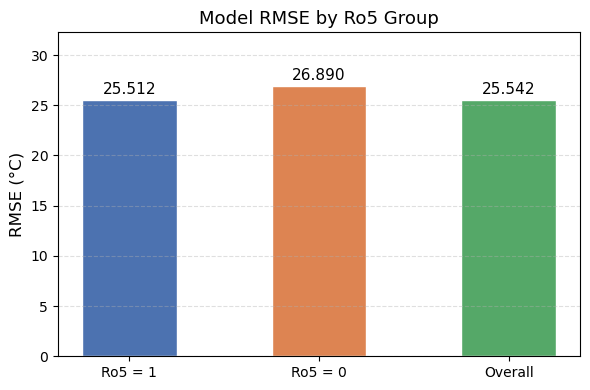

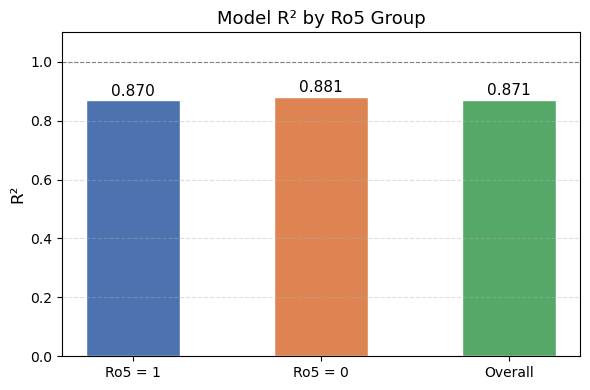

Evaluating model: XGB


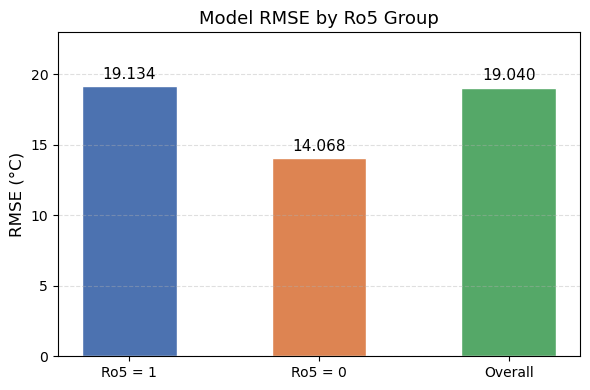

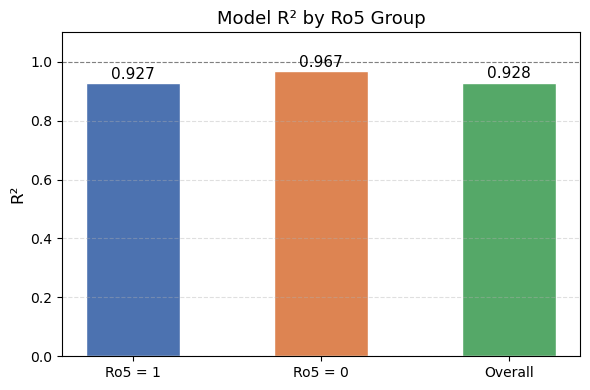

Evaluating model: LGB


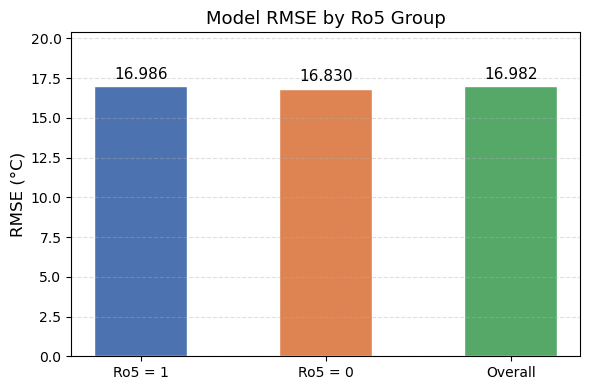

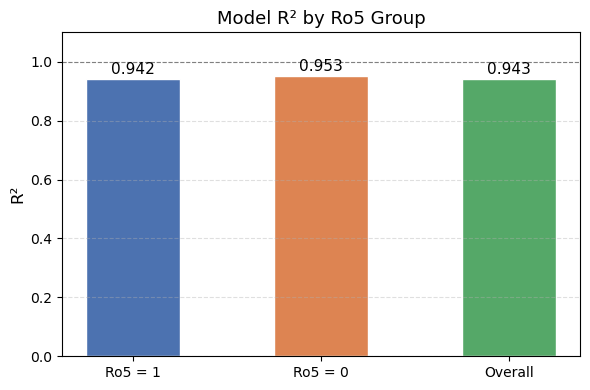

In [5]:
for model_name in model_types:

    print(f"Evaluating model: {model_name}")
    model_path = f'{model_prefix}best_model_{model_name}.joblib'
    model = joblib.load(model_path)
    data = pd.read_parquet(data_prefix + f"data_with_selected_features_{model_name}_scaled.parquet")
    data_test = data[data['Type']=='Test']
    mp_pred = model_evaluation(data_test, model)

    mp_pred.to_csv(f"model_evaluation_results_{model_name}.csv", index=False)